# Assignment 3 — Scalebar(s) & Restauration


**Student Name:** Sheylle Green and Marc Wijnands 

**Group Number:** 20


In [2]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import os

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org


## Part 3.1

---
### Question 1 and 2


In [3]:

def smooth_1d(data, sigma=20):

    window_size = int(sigma * 4) #  window size for Gaussian
    if window_size % 2 == 0: window_size += 1
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')

def find_1d_segments_centers(mask, min_length=1):

    # Find indices where mask is True
    indices = np.where(mask)[0]
    if len(indices) == 0:
        return [], 0
    
    # Find gaps in indices (where diff > 1)
    gaps = np.where(np.diff(indices) > 1)[0]
    
    centers = []
    start_idx = 0
    
    for gap_idx in gaps:
        segment = indices[start_idx : gap_idx + 1]
        if len(segment) >= min_length:
            centers.append(int(np.mean(segment)))
        start_idx = gap_idx + 1
    
    # Handle the last segment
    segment = indices[start_idx:]
    if len(segment) >= min_length:
        centers.append(int(np.mean(segment)))
        
    return centers, len(centers)

def measure_pixel_size(filepath, division_um=10.0, plot=True, imgname='image'):

    #  Load 
    img = dip.ImageReadTIFF(filepath)
    arr = np.array(img)
    h, w = arr.shape
    print(f'[{imgname}] Size: {w}x{h}px')

    #  Preprocessing 
    se_bg = dip.SE(150, 'rectangular')
    corrected = dip.Tophat(img, se_bg, polarity='black')
    thresh_img, thresh_val = dip.Threshold(corrected)
    
    # Morphological cleaning
    closed = dip.Closing(thresh_img, dip.SE(7, 'rectangular'))
    cleaned_img = dip.Opening(closed, dip.SE(3, 'rectangular'))
    clean_arr = np.array(cleaned_img).astype(bool)

    # Count Horizontal Line Starts 
    padded = np.pad(clean_arr.astype(int), ((1, 0), (0, 0)), mode='constant')
    diff = np.diff(padded, axis=0)
    starts = (diff == 1) 
    
    starts_per_col = starts.sum(axis=0)
    
    # Ignore the left 30% of the image
    search_start = int(w * 0.3)
    starts_search = starts_per_col.copy()
    starts_search[:search_start] = 0
    
    starts_smooth = smooth_1d(starts_search.astype(float), sigma=20)
    
    peak_x = np.argmax(starts_smooth)
    peak_val = starts_smooth[peak_x]
    
    print(f'  Max line starts (right side): {peak_val:.1f} at x={peak_x}')

    # Define ROI 
    threshold_level = 0.3 * peak_val
    valid_cols = np.where(starts_smooth > threshold_level)[0]
    
    if len(valid_cols) > 0:
        x_start = max(search_start, valid_cols[0] - 20) 
        x_end = min(w, valid_cols[-1] + 20)
    else:
        x_start = max(search_start, peak_x - 200)
        x_end = min(w, peak_x + 200)
        
    if x_end - x_start < 50:
        x_start = max(search_start, peak_x - 150)
        x_end = min(w, peak_x + 150)

    ruler_roi = clean_arr[:, x_start:x_end]
    
    if ruler_roi.sum() == 0:
        raise RuntimeError(f'[{imgname}] ROI is empty.')

    # Tick Locations to better understand 
    y_proj = ruler_roi.sum(axis=1)
    y_mask = y_proj > 10 
    
    tick_centers, ng = find_1d_segments_centers(y_mask, min_length=2)
    
    if ng < 3:
         y_mask = y_proj > 2
         tick_centers, ng = find_1d_segments_centers(y_mask, min_length=2)
         if ng < 3:
             raise RuntimeError(f'[{imgname}] Could not detect enough ticks (found {ng}).')

    tick_centers = np.sort(np.array(tick_centers))
    
    #  Calculate Spacing 
    spacings = np.diff(tick_centers)
    if len(spacings) == 0:
         raise RuntimeError("No spacings calculated.")
         
    median_sp = np.median(spacings)
    valid_sp = spacings[np.abs(spacings - median_sp) < 0.4 * median_sp]
    mean_sp = np.mean(valid_sp)
    
    pixel_size = division_um / mean_sp
    
    print(f'  ROI: cols {x_start}-{x_end}')
    print(f'  Ticks found: {len(tick_centers)}')
    print(f'  Mean spacing: {mean_sp:.2f} px = {division_um} µm')
    print(f'  Pixel size: {pixel_size:.4f} µm/px')

    # Plot 
    if plot:
        corr_arr = np.array(corrected)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f'{imgname}: pixel size = {pixel_size:.4f} µm/px', fontsize=14, fontweight='bold')

        axes[0].imshow(arr, cmap='gray')
        axes[0].set_title('(a) Original')
        axes[0].axis('off')

        axes[1].imshow(clean_arr, cmap='gray')
        for c in tick_centers:
            axes[1].axhline(c, color='red', alpha=0.5, lw=1)
        axes[1].set_title('(b) Cleaned Binary')
        axes[1].axis('off')

        if len(tick_centers) > 1:
            z_y0 = max(0, tick_centers[0] - 30)
            z_y1 = min(h, tick_centers[min(10, len(tick_centers)-1)] + 30)
            zoom = arr[z_y0:z_y1, x_start:x_end]
            axes[2].imshow(zoom, cmap='gray', aspect='auto')
            for c in tick_centers:
                if z_y0 <= c <= z_y1:
                    axes[2].axhline(c - z_y0, color='red', lw=1.5)
            axes[2].set_title(f'(c) Ruler Zoom\nspacing={mean_sp:.1f}px')

        plt.tight_layout()
        plt.show()

    return pixel_size, mean_sp

---
### Question 3 


[CamIm01] Size: 2584x1936px
  Max line starts (right side): 27.0 at x=1539
  ROI: cols 1444-2145
  Ticks found: 27
  Mean spacing: 58.62 px = 10.0 µm
  Pixel size: 0.1706 µm/px


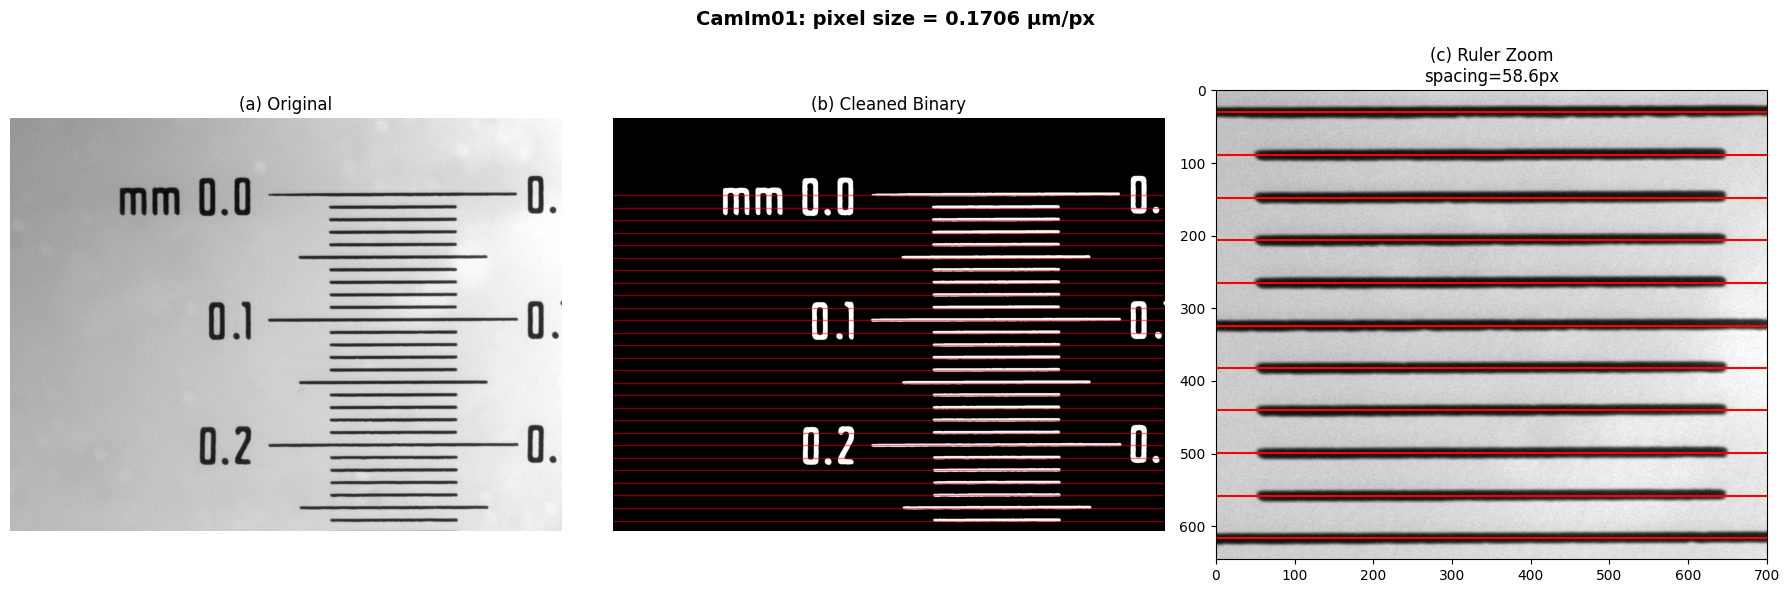

[CamIm02] Size: 2584x1936px
  Max line starts (right side): 15.0 at x=2156
  ROI: cols 2063-2584
  Ticks found: 15
  Mean spacing: 117.14 px = 10.0 µm
  Pixel size: 0.0854 µm/px


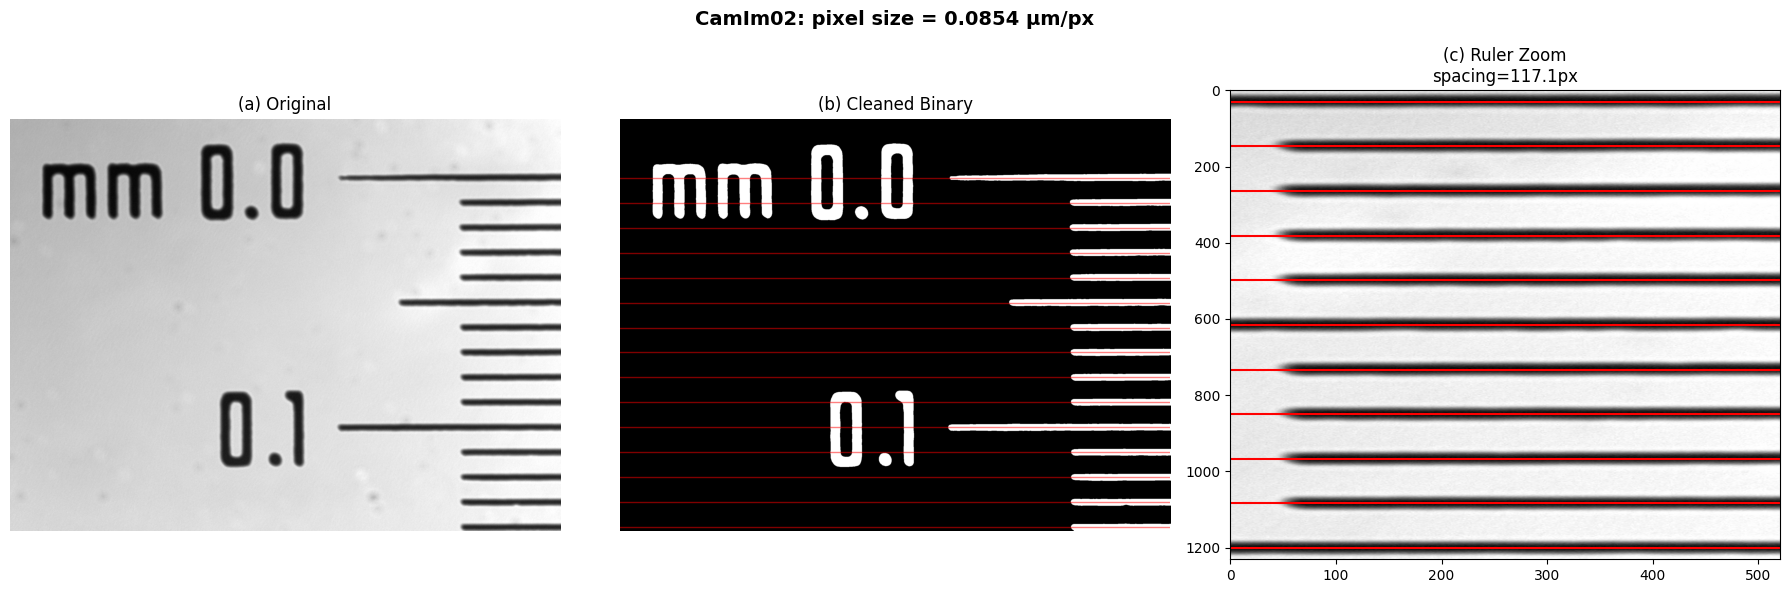

[CamIm03] Size: 2584x1936px
  Max line starts (right side): 6.0 at x=2120
  ROI: cols 1360-2584
  Ticks found: 6
  Mean spacing: 297.20 px = 10.0 µm
  Pixel size: 0.0336 µm/px


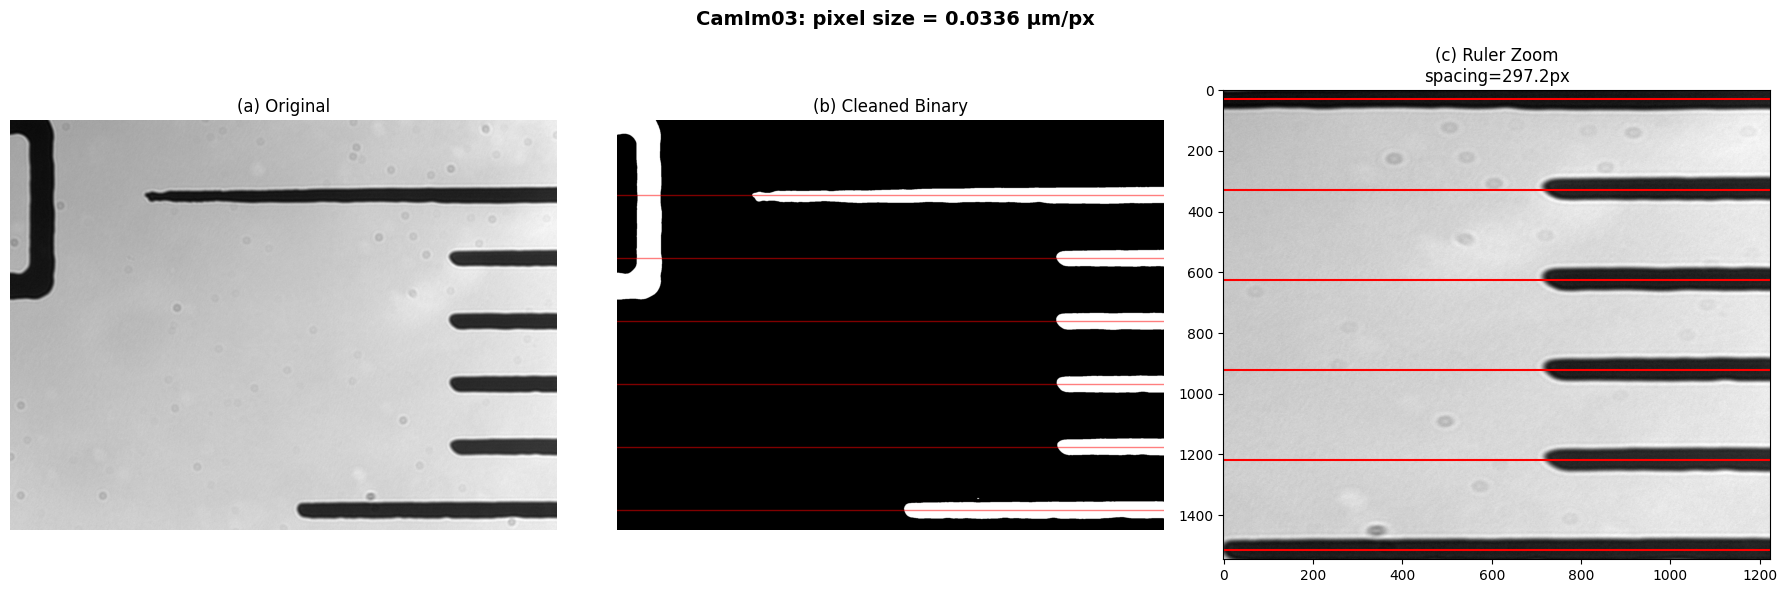


 PIXEL SIZE TABLE (Q3)
Image           Tick spacing (px)     Pixel size (µm/px)
--------------------------------------------------------
CamIm01                     58.62                 0.1706
CamIm02                    117.14                 0.0854
CamIm03                    297.20                 0.0336


In [4]:
# Run calibration on all three images
images = {
    'CamIm01': 'CamIm01.tif',
    'CamIm02': 'CamIm02.tif',
    'CamIm03': 'CamIm03.tif',
}

results = {}
for name, path in images.items():
    ps, sp = measure_pixel_size(path, division_um=10.0, plot=True, imgname=name)
    results[name] = {'pixel_size_um': ps, 'spacing_px': sp}

print('\n PIXEL SIZE TABLE (Q3)')
print(f'{"Image":<12} {"Tick spacing (px)":>20} {"Pixel size (µm/px)":>22}')
print('-'*56)
for name, r in results.items():
    print(f'{name:<12} {r["spacing_px"]:>20.2f} {r["pixel_size_um"]:>22.4f}')


---
### Question 4 


In [9]:
# CamIm03 is acquired at 100x
# Relationship: pixel_size * magnification = constant (for fixed camera sensor)
# => M_x = 100 * ps_100 / ps_x

ps_100x = results['CamIm03']['pixel_size_um']

print(' MAGNIFICATION TABLE (Q4)')
print(f'{"Image":<12} {"Pixel size (µm/px)":>22} {"Computed Mag (×)":>20} {"Probable Mag (×)":>20}')
print('-'*76)

standard_mags = [5, 10, 20, 40, 63, 100]
for name, r in results.items():
    ps = r['pixel_size_um']
    computed_mag = 100.0 * ps_100x / ps
    # Nearest standard magnification
    probable_mag = min(standard_mags, key=lambda m: abs(m - computed_mag))
    print(f'{name:<12} {ps:>22.4f} {computed_mag:>20.1f} {probable_mag:>20}')
    r['computed_mag'] = computed_mag
    r['probable_mag'] = probable_mag

print()
print('Explanation:')
print('The computed magnification (100 * ps_100 / ps_x) will deviate slightly from')
print('the nominal objective value due to:\n(1) discrete pixel measurement uncertainty,')
print('(2) tube lens or camera adapter magnification factor (typically 1.0× or 1.5×),')
print('and (3) optical tolerances of the objectives (~1-3%). The probable magnification')
print('is the nearest value from the standard series: 10×, 20×, 40×, 100×.')


 MAGNIFICATION TABLE (Q4)
Image            Pixel size (µm/px)     Computed Mag (×)     Probable Mag (×)
----------------------------------------------------------------------------
CamIm01                      0.1706                 19.7                   20
CamIm02                      0.0854                 39.4                   40
CamIm03                      0.0336                100.0                  100

Explanation:
The computed magnification (100 * ps_100 / ps_x) will deviate slightly from
the nominal objective value due to:
(1) discrete pixel measurement uncertainty,
(2) tube lens or camera adapter magnification factor (typically 1.0× or 1.5×),
and (3) optical tolerances of the objectives (~1-3%). The probable magnification
is the nearest value from the standard series: 10×, 20×, 40×, 100×.


## Part 3.2

---
### Question 5

In [10]:
ics_filename = './scale-img.ics'

try:
    with open(ics_filename, 'r') as f:
        header_text = f.read()
    
    print("Content of the .ics header file:")
    print(header_text)

except FileNotFoundError:
    print(f"Error: '{ics_filename}' not found. Please check the file path.")



Content of the .ics header file:
	
ics_version	1.0
filename	scale-img
layout	parameters	3
layout	order	bits	x	y
layout	sizes	32	256	256
layout	coordinates	video
layout	significant_bits	32
representation	format	real
representation	sign	signed
representation	byte_order	4	3	2	1
representation	SCIL_TYPE	f2d



---
### Question 6

In [11]:
tif_filename = 'scale-img.tif'

try:
    # 1. Read both images
    # DIPlib automatically handles the .ics header and loads the associated .ids data
    img_tif = dip.ImageRead(tif_filename)
    img_ics = dip.ImageRead(ics_filename)
    
    # Convert to numpy arrays for numerical analysis
    arr_tif = np.array(img_tif)
    arr_ics = np.array(img_ics)
    
    print(f"Loaded TIFF shape: {arr_tif.shape}, dtype: {arr_tif.dtype}")
    print(f"Loaded ICS shape:  {arr_ics.shape}, dtype: {arr_ics.dtype}")
    
    # File Size Comparison
    size_tif = os.path.getsize(tif_filename)
    size_ics_header = os.path.getsize(ics_filename)
    
    ids_filename = ics_filename.replace('.ics', '.ids')
    size_ids_data = os.path.getsize(ids_filename)
    
    total_ics_size = size_ics_header + size_ids_data
    
    print(f"\nFile Size Comparison:")
    print(f"  TIFF file size:       {size_tif / 1024:.2f} KB")
    if size_ids_data > 0:
        print(f"  ICS Header size:      {size_ics_header / 1024:.2f} KB")
        print(f"  IDS/IFS Data size:    {size_ids_data / 1024:.2f} KB")
        print(f"  Total ICS size:       {total_ics_size / 1024:.2f} KB")
        
except Exception as e:
    print(f"Error during comparison: {e}")
    import traceback
    traceback.print_exc()

Loaded TIFF shape: (256, 256), dtype: uint8
Loaded ICS shape:  (256, 256), dtype: float32

File Size Comparison:
  TIFF file size:       64.23 KB
  ICS Header size:      0.27 KB
  IDS/IFS Data size:    256.00 KB
  Total ICS size:       256.27 KB
